### Robot World 1-D

First, imagine you have a robot living in a 1-D world. You can think of a 1D world as a one-lane road. 

<img src="images/road_1.png" width="50%" height="50%">

### Uniform Distribution
Since the robot does not know where it is at first, the probability of being in any space is the same

In [ ]:
# uniform distribution for 5 grid cells
# we use "p" to represent probability
p = [0.2, 0.2, 0.2, 0.2, 0.2]
print(p)

In [10]:
# importing resources
import matplotlib.pyplot as plt
import numpy as np

In [11]:
def display_map(grid, bar_width=1):
    if(len(grid) > 0):
        x_labels = range(len(grid))
        plt.bar(x_labels, height=grid, width=bar_width, color='b')
        plt.xlabel('Grid Cell')
        plt.ylabel('Probability')
        plt.ylim(0, 1) # range of 0-1 for probability values 
        plt.title('Probability of the robot being at each cell in the grid')
        plt.xticks(np.arange(min(x_labels), max(x_labels)+1, 1))
        plt.show()
    else:
        print('Grid is empty')


[0.2, 0.2, 0.2, 0.2, 0.2]


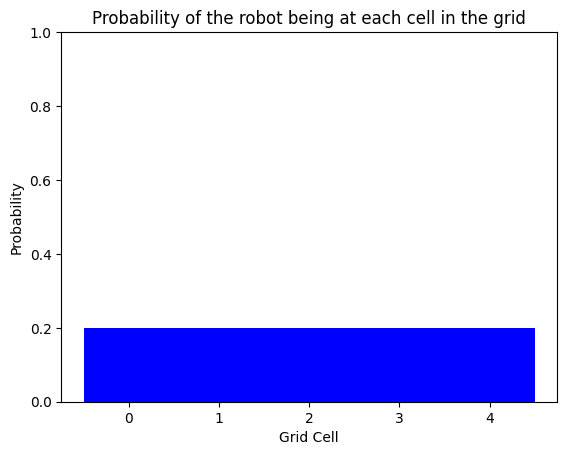

In [12]:
display_map(p)

<h3>Our Virtual enviroment parameters</h3>

1. The robot starts off knowing nothing; the robot is equally likely to be anywhere and so `p` is a uniform distribution.
2. Then the robot senses a grid color: red or green, and updates this distribution `p` according to the values of pHit and pMiss.

* The probability that it is sensing the color correctly is `pHit = 0.6`.
* The probability that it is sensing the wrong color is `pMiss = 0.2`

<img src='images/robot_sensing.png' width=50% height=50% />

<h3>Our Virtual enviroment parameters</h3>

In [3]:
# given initial variables
p=[0.2, 0.2, 0.2, 0.2, 0.2]
# the color of each grid cell in the 1D world
world=['green', 'red', 'red', 'green', 'green']
# Z, the sensor reading ('red' or 'green')
measurements = ['red', 'red']
pHit = 0.6
pMiss = 0.2

motions = [1,1]
pExact = 0.8
pOvershoot = 0.1
pUndershoot = 0.1

In [4]:
def sense(p, Z):
    ''' Takes in a current probability distribution, p, and a sensor reading, Z.
        Returns a *normalized* distribution after the sensor measurement has been made, q.
        This should be accurate whether Z is 'red' or 'green'. '''
    # solution
    q = []
    for i in range(len(p)):
        if(world[i] == Z):
            q.append(p[i]*pHit)
        else:
            q.append(p[i]*pMiss)
    norm = sum(q[i] for i in range (len(q)))
    for i in range(len(q)):
        q[i] = q[i]/norm
    return q

<img src='images/motion_1.png' width=50% height=50% /> 
<img src='images/uncertain_motion.png'  width=50% height=50%/>


In [13]:
def move(p, U):
    q=[]
    # iterate through all values in p
    for i in range(len(p)):
        # use the modulo operator to find the new location for a p value
        # this finds an index that is shifted by the correct amount
        index = (i-U) % len(p)
        nextIndex = (index+1) % len(p)
        prevIndex = (index-1) % len(p)
        s = pExact * p[index]
        s = s + pOvershoot  * p[nextIndex]
        s = s + pUndershoot * p[prevIndex]
        # append the correct, modified value of p to q
        q.append(s)
    return q

<img src='images/sense_move.png' width=50% height=50% />

[0.24572313182199831, 0.14064861460957181, 0.13890638119227544, 0.22514693534844668, 0.2495749370277078]


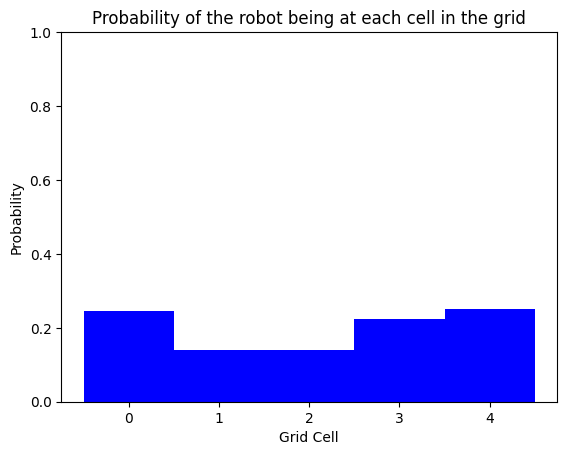

In [8]:
for m in range(len(measurements)):
    p = sense(p, measurements[m])
    p = move(p, motions[m])
    
print(p)
display_map(p)

As you can see the Robot gives higher probability for the correct likehood cell